In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncx2
from scipy.special import iv

In [24]:
# Parameters

a = 0 # left trunctation
b = 50 # right truncatation
n = 10000 # grid intervals
k = 5 # degrees of freedom
nc = 5 # non central parameter
alpha = k/2 - 1 # first para for modified bessal of the first kind
x = np.linspace(a, b, n)


In [25]:
#  noncentral chi-squared distribution

f1 = ncx2.pdf(x, k, nc)

f2 = np.zeros(n) # with bessfal function

for i in range(n):
    f2[i] = 0.5 * np.exp(-(x[i] + nc)/2) * (x[i] /nc)**(k/4 -1/2) * iv(alpha,np.sqrt(nc*x[i]))

In [28]:
# Sampling 

size = 10000000
samples = ncx2.rvs(k, nc, size= size)

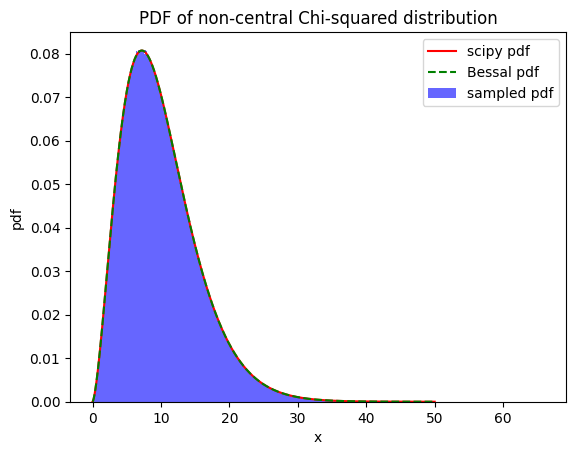

In [29]:
plt.plot(x, f1, 'r', label = 'scipy pdf')
plt.plot(x, f2, 'g--', label = 'Bessal pdf')
plt.hist(samples, bins=1000, density=True, alpha=0.6, color='b', label = 'sampled pdf')
plt.legend()
plt.xlabel('x')
plt.ylabel('pdf')
plt.title('PDF of non-central Chi-squared distribution')
plt.show()


In [68]:
# Define the parameters
k = 5  # degrees of freedom
lambda_ = 5  # non-centrality parameter
a = 0  # left truncation
b = 35  # right truncation
N = 128  # number of grid steps
nsample = int(2 * 10**6)  # number of random samples

# Grid in real space
dx = (b - a) / N  # grid step
x = np.linspace(a, b - dx, N) # Non central chi is on postive axis

# Grids in Fourier space
dxi = np.pi / b  # Nyquist relation
xi = dxi * np.arange(-N, N)

In [69]:
# Characteristic function as per Eq. (49)
phi = (np.exp((1j * lambda_ * xi) / (1 - 2j * xi)) /(1 - 2j * xi)**(k / 2))

fc = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(phi))) / (2 * b)

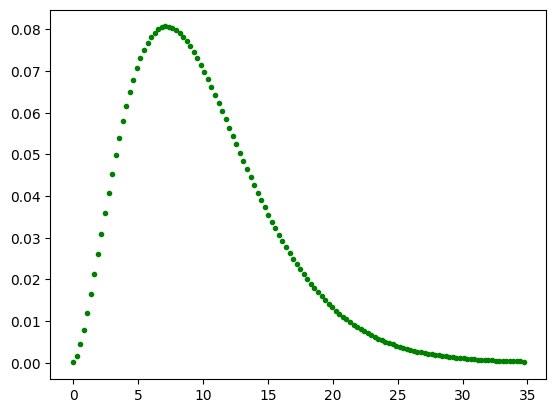

In [70]:
plt.plot(x, np.real(fc[N:]), 'g.', label='Theory c) Fourier', linewidth=2) # N: is the real part.